In [19]:
from scipy.special import gammaln
from scipy.stats import ks_2samp
import matplotlib
import matplotlib as mpl
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
import healpy as hp
from astropy.io import fits
from astropy import conf
from astropy.table import Table, vstack, hstack, join
from astropy.coordinates import Distance
from astropy.cosmology import Planck18, LambdaCDM
import numpy as np
import fitsio
import numpy.lib.recfunctions as rfn
import os
import pickle
import vast.catalog.void_catalog as void_catalog

## Generate Tables

In [2]:
#Load data

galaxy_table = Table.read(
    '/global/homes/j/jkneiss/galaxy_table_DR2_voids.fits',
    format='fits'
)

metallicity_table = Table.read('/global/cfs/cdirs/desi/users/dscholte/data_to_share/ohno/final-catalog-loa-combined-auroral.fits')

galaxy_metallicity = join(metallicity_table, galaxy_table, keys=['TARGETID'] )


In [3]:
#Fix metallicity table to data range
galaxy_metallicity['OH_p50'] += 12
galaxy_metallicity = galaxy_metallicity[galaxy_metallicity['Z'] <= .24]
galaxy_metallicity = galaxy_metallicity[(galaxy_metallicity['ABSMAG01_SDSS_R'] <= -14) & (galaxy_metallicity['ABSMAG01_SDSS_R'] >= -20)]
galaxy_metallicity = galaxy_metallicity[(galaxy_metallicity['OH_p50'] >= -50) & (galaxy_metallicity['NH_p50'] >= -50)]

In [4]:
galaxy_table['ra'].name = 'RA'
galaxy_table['dec'].name = 'DEC'
galaxy_table['redshift'].name = 'Z'

## Define Helper Functions

In [5]:
def get_property(prop_name, algorithm, environment, sample, metallicity=False):
    """ 
    select galaxy property

    prop_name: name of property

    algorithm: name of void-finding algorithm

    environment: name of galaxy environment for selection (void, wall, or all)

    sample: DESI tracer used for selection

    """
    if metallicity == True:
        gals = galaxy_metallicity
    elif metallicity == False:
        gals = galaxy_table
    
    if environment == 'void':
        gals = gals[gals[f'{algorithm}_FLAG'] == 1]
    elif environment == 'wall':
        gals = gals[gals[f'{algorithm}_FLAG'] == 0]
    elif environment == 'all':
        gals = gals[(gals[f'{algorithm}_FLAG'] == 0) + (gals[f'{algorithm}_FLAG'] == 1)]
    else:
        raise ValueError('Invalid environment:', environment)

    if sample == 'BGS':
        gals = gals[(gals['BGS_TARGET'] & 2**1 != 0) + (gals['BGS_TARGET'] & 2**0 != 0)]
    elif sample == 'BGS Bright':
        gals = gals[(gals['BGS_TARGET'] & 2**1 != 0)]
    elif sample != "DR2":
        raise ValueError('Invalid sample:', sample)
        
    if prop_name.lower() in ['m_r', 'mr', 'rabsmag']:
        return gals['ABSMAG01_SDSS_R']
    elif prop_name.lower() in ['log_mstar', 'logmstar']:
        return gals['LOGMSTAR']
    elif prop_name.lower() in ['color_ur', 'ur', 'u-r']:
        return gals['ABSMAG01_SDSS_U'] - gals['ABSMAG01_SDSS_R']
    elif prop_name.lower() in ['color_gr', 'gr', 'g-r']:
        return gals['ABSMAG01_SDSS_G'] - gals['ABSMAG01_SDSS_R']
    elif prop_name.lower() in ['oh_p50']:
        return gals['OH_p50']
    elif prop_name.lower() in ['no', 'n/o']:
        return gals['NH_p50'] - gals['OH_p50']
        
    elif prop_name.lower() in ['halpha', 'halpha_ew']:
        return gals['HALPHA_EW']
    elif prop_name.lower() in ['log_halpha', 'log_halpha_ew']:
        halpha = np.full(len(gals), -np.inf)
        halpha[gals['HALPHA_EW']>0] = np.log10(gals['HALPHA_EW'][gals['HALPHA_EW']>0])
        return halpha
    elif prop_name.lower() == 'sfr':
        return gals['SFR']
    elif prop_name.lower() in ['z', 'redshift']:
        return gals['Z']
    #elif prop_name.lower() == '':
    #    return gals['']
    else:
        raise ValueError('Invalid Property:'+prop_name)

## Define Plotting Functions

In [6]:
def get_mr_z_bin(redshift, zmin, zmax, mr, mrmin, mrmax, galaxy_property, prop_name):

    select = (redshift < zmax) * (redshift > zmin) * (mr < mrmax) * (mr > mrmin)
    if prop_name == 'halpha':
        galaxy_property=galaxy_property[select]
        galaxy_property = galaxy_property[galaxy_property>0]
        prop = np.log10(galaxy_property)
        prop = prop[(prop>-3)*(prop<5)]
        return prop
    return galaxy_property[select]

In [7]:
def property_histograms_data(prop_name, num_mr_bins=7, num_z_bins=7, mr_min=-20, mr_max=-17, lim17=True, sample='BGS Bright'):
    """
    For each (Mr, z) bin used in plot_bayes_factor_heatmap, 
    plot a histogram comparing the galaxy property distribution
    for void vs wall galaxies.
    """

    #Set metallicity
    if prop_name.lower() in ['oh_p50','no', 'n/o']:
        metallicity = True
    else:
        metallicity = False

    # Load data
    void_property = get_property(prop_name, 'VF', 'void', sample, metallicity)
    wall_property = get_property(prop_name, 'VF', 'wall', sample, metallicity)
    void_redshift = get_property('z', 'VF', 'void', sample, metallicity)
    wall_redshift = get_property('z', 'VF', 'wall',sample, metallicity)
    all_redshift = get_property('z', 'VF', 'all',sample, metallicity)
    void_mr = get_property('mr', 'VF', 'void', sample, metallicity)
    wall_mr = get_property('mr', 'VF', 'wall', sample, metallicity)
    all_mr = get_property('mr', 'VF', 'all', sample, metallicity)

    # Define M_r quantile bins
    if lim17 == True:
        mr_mask_low = (all_mr >= mr_min) & (all_mr < -17)
        low_bins = np.quantile(all_mr[mr_mask_low],
            np.linspace(0, 1, num_mr_bins))
        low_bins[-1] = -17
        mr_bins = np.append(low_bins, mr_max)
    else:
        mr_mask = (all_mr >= mr_min) & (all_mr <= mr_max)
        mr_bins = np.quantile(all_mr[mr_mask],
                              np.linspace(0, 1, num_mr_bins+1))
    results=[]
    for mr_i, (mrmin, mrmax) in enumerate(zip(mr_bins[:-1], mr_bins[1:])):

        # Determine redshift bins
        void_pre_bin = get_mr_z_bin(void_redshift, 0, np.inf, void_mr, mrmin, mrmax, void_redshift, 'redshift')
        wall_pre_bin = get_mr_z_bin(wall_redshift, 0, np.inf, wall_mr, mrmin, mrmax, wall_redshift, 'redshift')
        combined_pre_bin = get_mr_z_bin(all_redshift, 0, np.inf, all_mr, mrmin, mrmax, all_redshift, 'redshift')

        if len(combined_pre_bin) == 0:
            continue

        z_bins = np.quantile(combined_pre_bin, np.linspace(0, 1, num_z_bins+1))

        # Loop over z bins
        for z_i, (zmin, zmax) in enumerate(zip(z_bins[:-1], z_bins[1:])):

            # Select property values for the bin
            void_bin = get_mr_z_bin(void_redshift, zmin, zmax, void_mr, mrmin, mrmax, 
                                    void_property, prop_name)
            wall_bin = get_mr_z_bin(wall_redshift, zmin, zmax, wall_mr, mrmin, mrmax, 
                                    wall_property, prop_name)

            # Need data from both environments
            if len(void_bin) == 0 or len(wall_bin) == 0:
                continue
            """
            # Same downsampling as heatmap
            min_len = min(len(void_bin), len(wall_bin))
            np.random.seed(0)
            void_bin = np.random.choice(void_bin, min_len, replace=False)
            wall_bin = np.random.choice(wall_bin, min_len, replace=False)
            """
            results.append((mr_i, z_i, mrmin, mrmax, zmin, zmax, void_bin, wall_bin))

    return(results)

In [20]:
def plot_heatmap(prop_name, num_mr_bins=6, num_z_bins=6, linewidth=.2, axsize=20, color='PiYG', sample='BGS', ax=None, mr_min=-20, mr_max=-17, lim17=False):
    """
    Plot Bayes factor heatmap of Wall vs void
    of property for different mr and redshift bins

    prop_name: galaxy property to be plotted

    num_mr/z_bins: int
                   Number of bins the galaxies are seperated into for final heatmap

    Sample: Which survey used for galaxies
            BGS for Bright+Faint, BGS Bright for Bright
    
    Lim17: Boolean
           Force magnitude bin for mr_max to Mr=-17
    """
    if ax is None:
        fig, ax = plt.subplots()

    
    #Check if metallicity
    if prop_name.lower() in ['oh_p50','no', 'n/o']:
        metallicity = True
    else:
        metallicity = False

    # Load data
    void_property = get_property(prop_name, 'VF', 'void', sample, metallicity)
    wall_property = get_property(prop_name, 'VF', 'wall', sample, metallicity)
    void_redshift = get_property('z', 'VF', 'void', sample, metallicity)
    wall_redshift = get_property('z', 'VF', 'wall',sample, metallicity)
    all_redshift = get_property('z', 'VF', 'all',sample, metallicity)
    void_mr = get_property('mr', 'VF', 'void', sample, metallicity)
    wall_mr = get_property('mr', 'VF', 'wall', sample, metallicity)
    all_mr = get_property('mr', 'VF', 'all', sample, metallicity)

    # Initialize KS storage
    ks_test = {
        'ks': [],
        'void_counts': [],
        'wall_counts': [],
        'zmin': [],
        'zmax': [],
        'mrmin': [],
        'mrmax': []
    }

    # Define magnitude bins (M_r)
    if lim17 == True:
        mr_mask1 = (all_mr >= -17) & (all_mr <= mr_max)
        mr_mask2 = (all_mr >= mr_min) & (all_mr < -17)
        mr_bins= np.concatenate([np.quantile(all_mr[mr_mask1], np.linspace(0,1,2)), 
                                 np.quantile(all_mr[mr_mask2],
                                 np.linspace(0,1,num_mr_bins))])
    else:
        mr_mask = (all_mr >= mr_min) & (all_mr <= mr_max)
        mr_bins = np.quantile(all_mr[mr_mask],
                              np.linspace(0, 1, num_mr_bins+1))

    for mrmin, mrmax in zip(mr_bins[:-1], mr_bins[1:]):
        # Determine redshift bins
        void_pre_bin = get_mr_z_bin(void_redshift, 0, np.inf, void_mr, mrmin, mrmax, void_redshift, 'redshift')
        wall_pre_bin = get_mr_z_bin(wall_redshift, 0, np.inf, wall_mr, mrmin, mrmax, wall_redshift, 'redshift')
        combined_pre_bin = get_mr_z_bin(all_redshift, 0, np.inf, all_mr, mrmin, mrmax, all_redshift, 'redshift')

        if len(combined_pre_bin) == 0:
            continue

        z_bins = np.quantile(combined_pre_bin, np.linspace(0, 1, num_z_bins+1))

        for zmin, zmax in zip(z_bins[:-1], z_bins[1:]):
            void_bin = get_mr_z_bin(void_redshift, zmin, zmax, void_mr, mrmin, mrmax, void_property, prop_name)
            wall_bin = get_mr_z_bin(wall_redshift, zmin, zmax, wall_mr, mrmin, mrmax, wall_property, prop_name)

            #Get Bayes Factors
            if len(void_bin) > 0 and len(wall_bin) > 0:
                """
                # Downsample to equal sizes
                min_len = min(len(void_bin), len(wall_bin))
                np.random.seed(0)
                void_bin = np.random.choice(void_bin, min_len, replace=False)
                wall_bin = np.random.choice(wall_bin, min_len, replace=False)
                """

                ks = np.log(ks_2samp(wall_bin, void_bin).pvalue)
                ks = 0 if not np.isfinite(ks) else ks

                ks_test['ks'].append(ks)
                ks_test['void_counts'].append(len(void_bin))
                ks_test['wall_counts'].append(len(wall_bin))
                ks_test['zmin'].append(zmin)
                ks_test['zmax'].append(zmax)
                ks_test['mrmin'].append(mrmin)
                ks_test['mrmax'].append(mrmax)

    # Set up heatmap
    cmap = matplotlib.colormaps[color]
    minima = min(ks_test['ks'])
    maxima = max(ks_test['ks'])
    lim= max(abs(minima),abs(maxima))
    norm = matplotlib.colors.Normalize(vmin=-lim, vmax=lim, clip=True)
    mapper = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)

    rectangles = []
    counts = []


    for zmin, zmax, mrmin, mrmax, ks, void, wall in zip(
            ks_test['zmin'], ks_test['zmax'],
            ks_test['mrmin'], ks_test['mrmax'],
            ks_test['ks'],
            ks_test['void_counts'], ks_test['wall_counts']):
        rectangles.append(Rectangle((zmin, mrmin), zmax - zmin, mrmax - mrmin, facecolor=cmap(norm(ks)), linewidth=linewidth))
        counts.append(void + wall)

    collection = PatchCollection(rectangles, alpha=0.6, match_original=True)
    ax.add_collection(collection)

    #plot
    ax.set_xlim(0, 0.25)
    ax.set_ylim(mr_min, mr_max)
    plt.gca().invert_yaxis()
    plt.xlabel('Redshift', fontsize=16)
    plt.xticks(fontsize=12)
    plt.ylabel('$M_r$', fontsize=16)
    plt.yticks(fontsize=12)
    cbar = plt.colorbar(mapper, ax=ax)
    cbar.set_label('ln(KS)', fontsize=16)
    plt.title(f'Void-Wall Galaxy {prop_name} Comparison ', fontsize=20)
    #plt.savefig('Filename.png', dpi=300, bbox_inches='tight')
    #plt.show()


In [9]:
def plot_heatmap_and_hist(prop_name, num_mr_bins=6, num_z_bins=6, mr_min=-20, mr_max=-17, lim17 = True, sample='BGS', density = True):
    """ 
    Plot Bayes Factor Heatmap in grid with 
    diagnostic histograms across mr and z bins

    prop_name: galaxy property to be plotted

    num_mr/z_bins: int
                   Number of bins the galaxies are seperated into for final heatmap

    Sample: Which survey used for galaxies
            BGS for Bright+Faint, BGS Bright for Bright
    
    Lim17: Boolean
           Force magnitude bin for mr_max to Mr=-17

    Density: Input for histogram plotting density True or False
    """
    
    hist_data = property_histograms_data(prop_name,num_mr_bins,num_z_bins, mr_min=mr_min, mr_max=mr_max, lim17=lim17, sample=sample)

    mr_indices = [mr_i for mr_i, *_ in hist_data]
    nrows = max(mr_indices) + 1
    ncols = num_z_bins + 2

    fig = plt.figure(figsize=(10+2*nrows, 2*nrows), constrained_layout=True)
    gs = GridSpec(nrows, ncols + 5, figure=fig)


    ax_heatmap = fig.add_subplot(gs[:, :5])

    plot_heatmap(prop_name,
                num_mr_bins=num_mr_bins,
                num_z_bins=num_z_bins,
                ax=ax_heatmap, mr_min=mr_min, mr_max=mr_max, lim17 = lim17, sample=sample)


    for (mr_i, z_i, mrmin, mrmax, zmin, zmax,
         void_bin, wall_bin) in hist_data:

        ax = fig.add_subplot(gs[mr_i, z_i + 5])

        wall_bins = np.arange(min(wall_bin), max(wall_bin) + .1, .1)
        
        
        ax.hist(wall_bin, bins=wall_bins,
                histtype='step', color='black', alpha =.6, density = density)

        void_bins = np.arange(min(void_bin), max(void_bin) + .1, .1)
        
        ax.hist(void_bin, bins=void_bins,
                histtype='step', color='red', alpha=.6, density = density)
        """
        ax.set_title(
            f"{mrmin:.2f} < M_r < {mrmax:.2f}\n"
            f"{zmin:.3f} < z < {zmax:.3f}",
            fontsize=8
        )
        """

        if mr_i == nrows - 1:
            ax.set_xlabel(prop_name)

        if z_i == 0:
            ax.set_ylabel("Count")

        ax.tick_params(labelsize=7)

    #plt.savefig('Filename.png', dpi=300, bbox_inches='tight')

    plt.show()

## Plotting

In [10]:
#Comment out plt.show() in plot_heatmap so it does not end plotting early in the histogram function

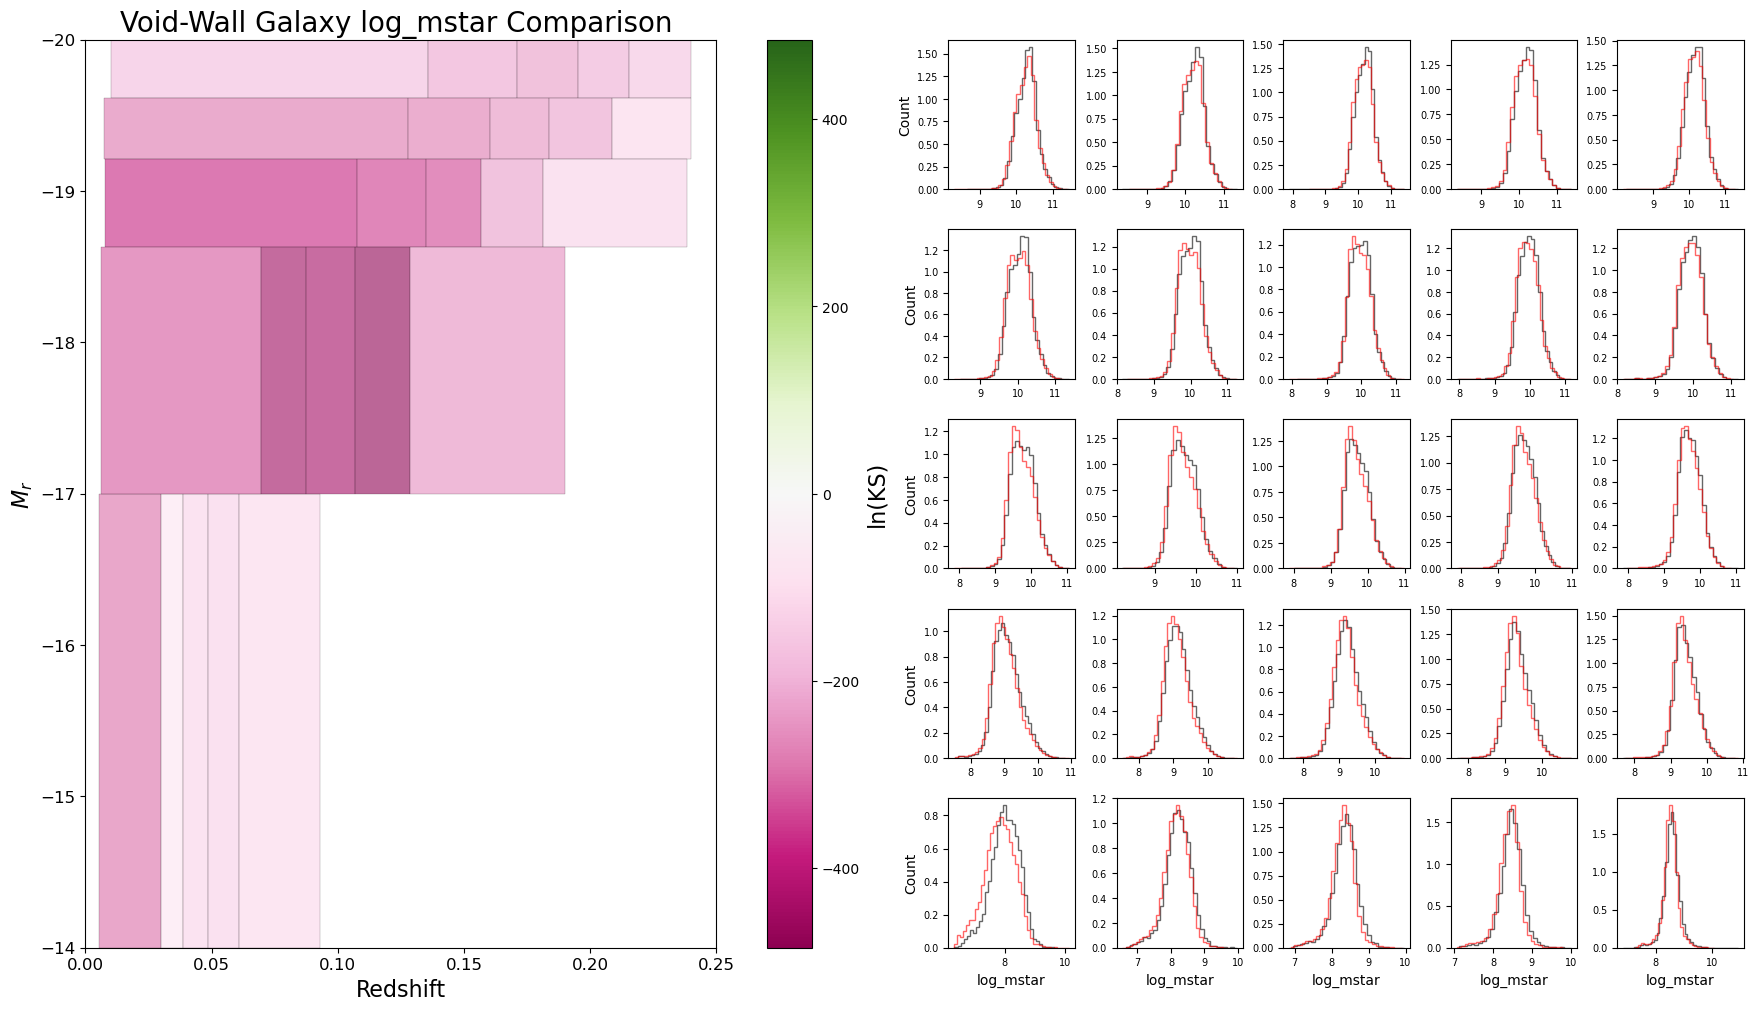

/tmp/ipykernel_273222/8898748.py:85: RuntimeWarning: divide by zero encountered in log
  ks = np.log(ks_2samp(wall_bin, void_bin).pvalue)


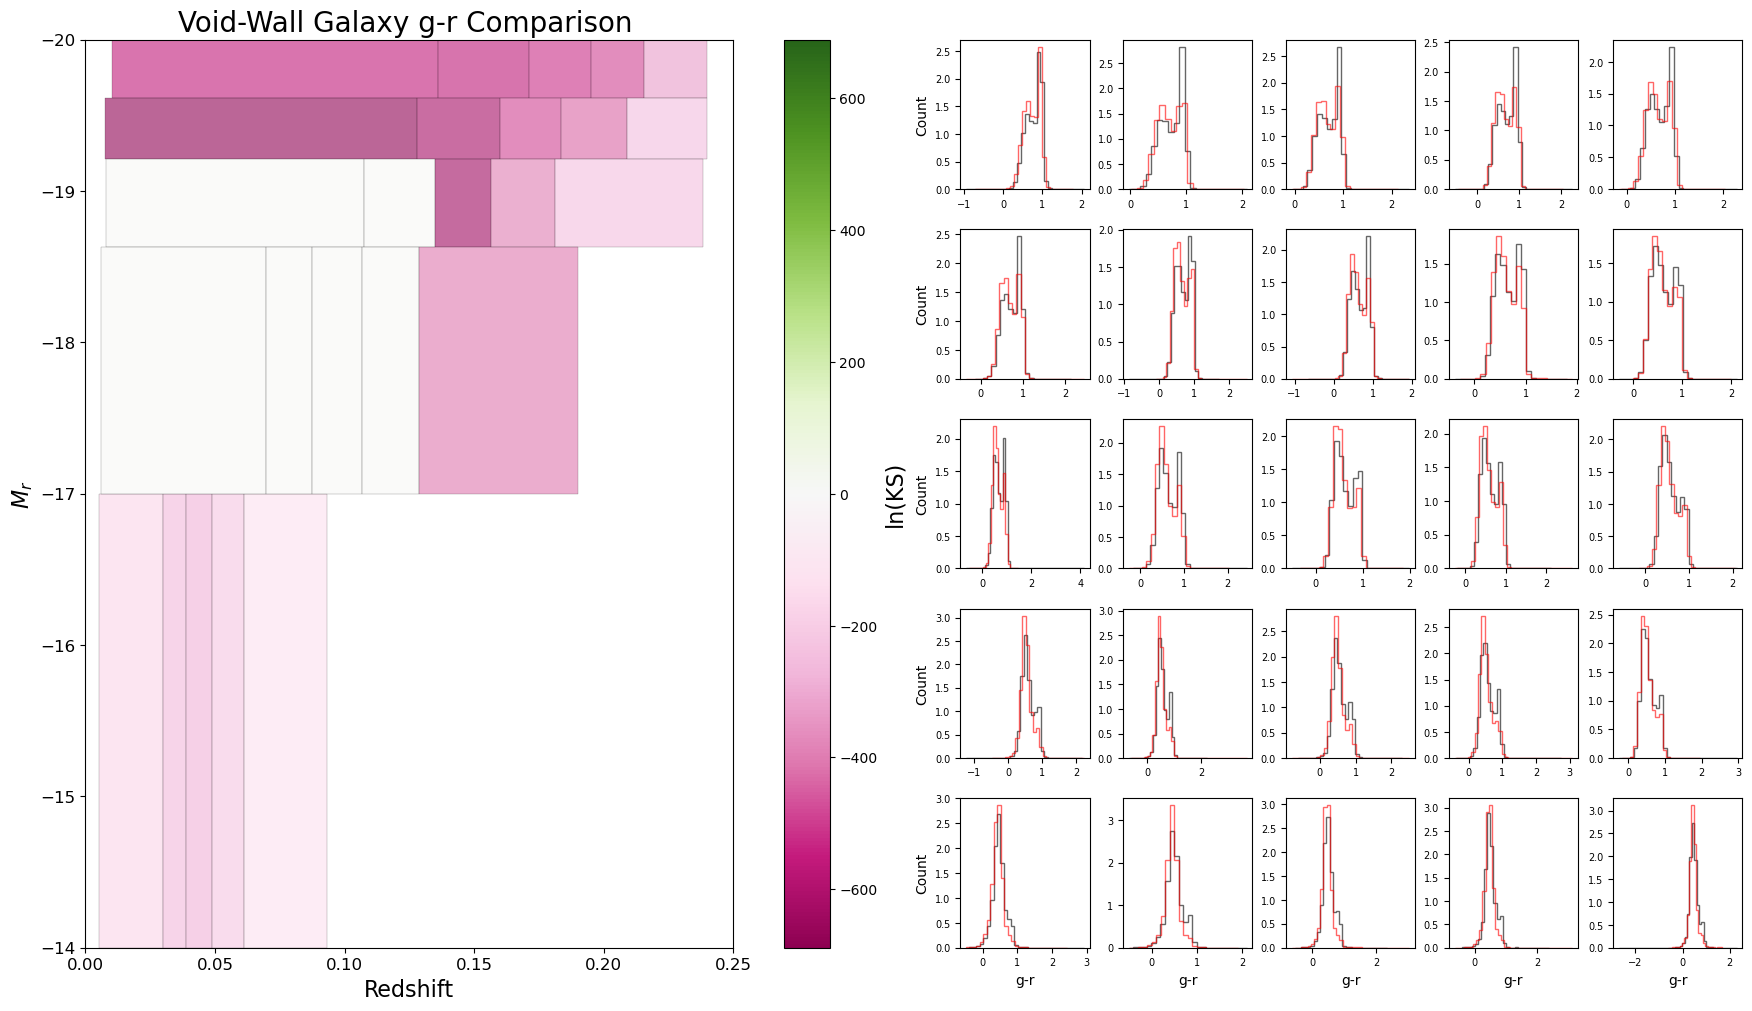

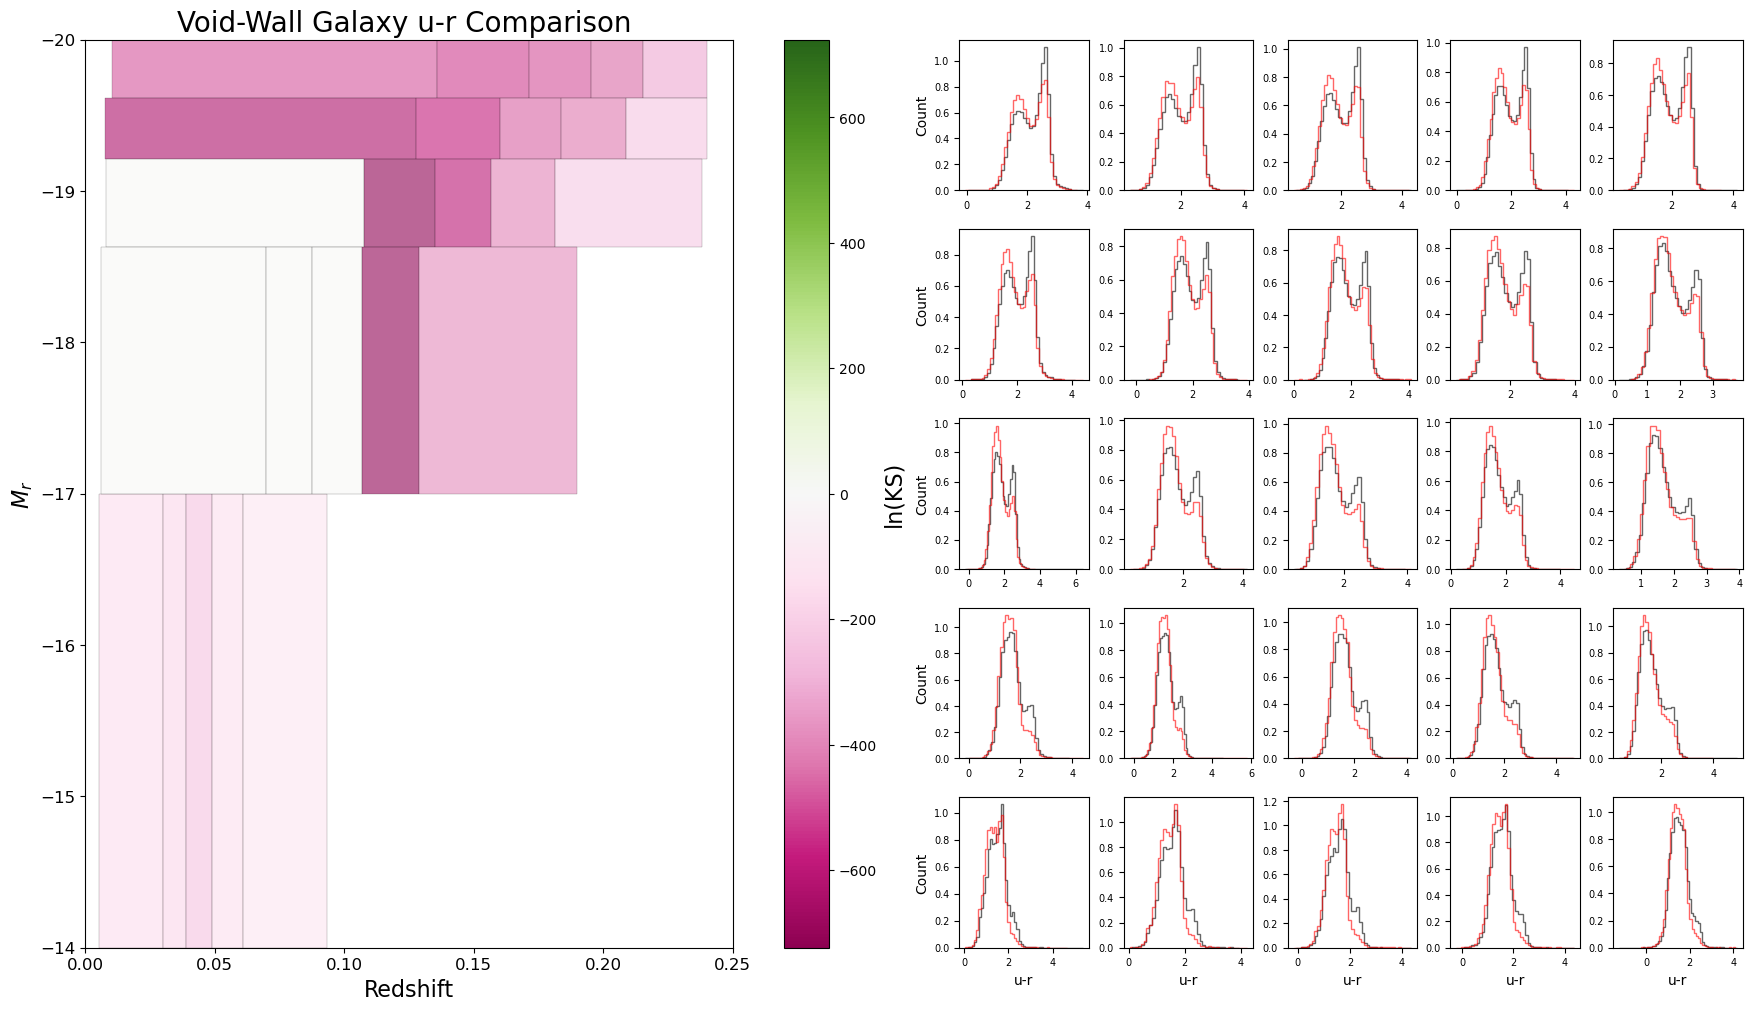

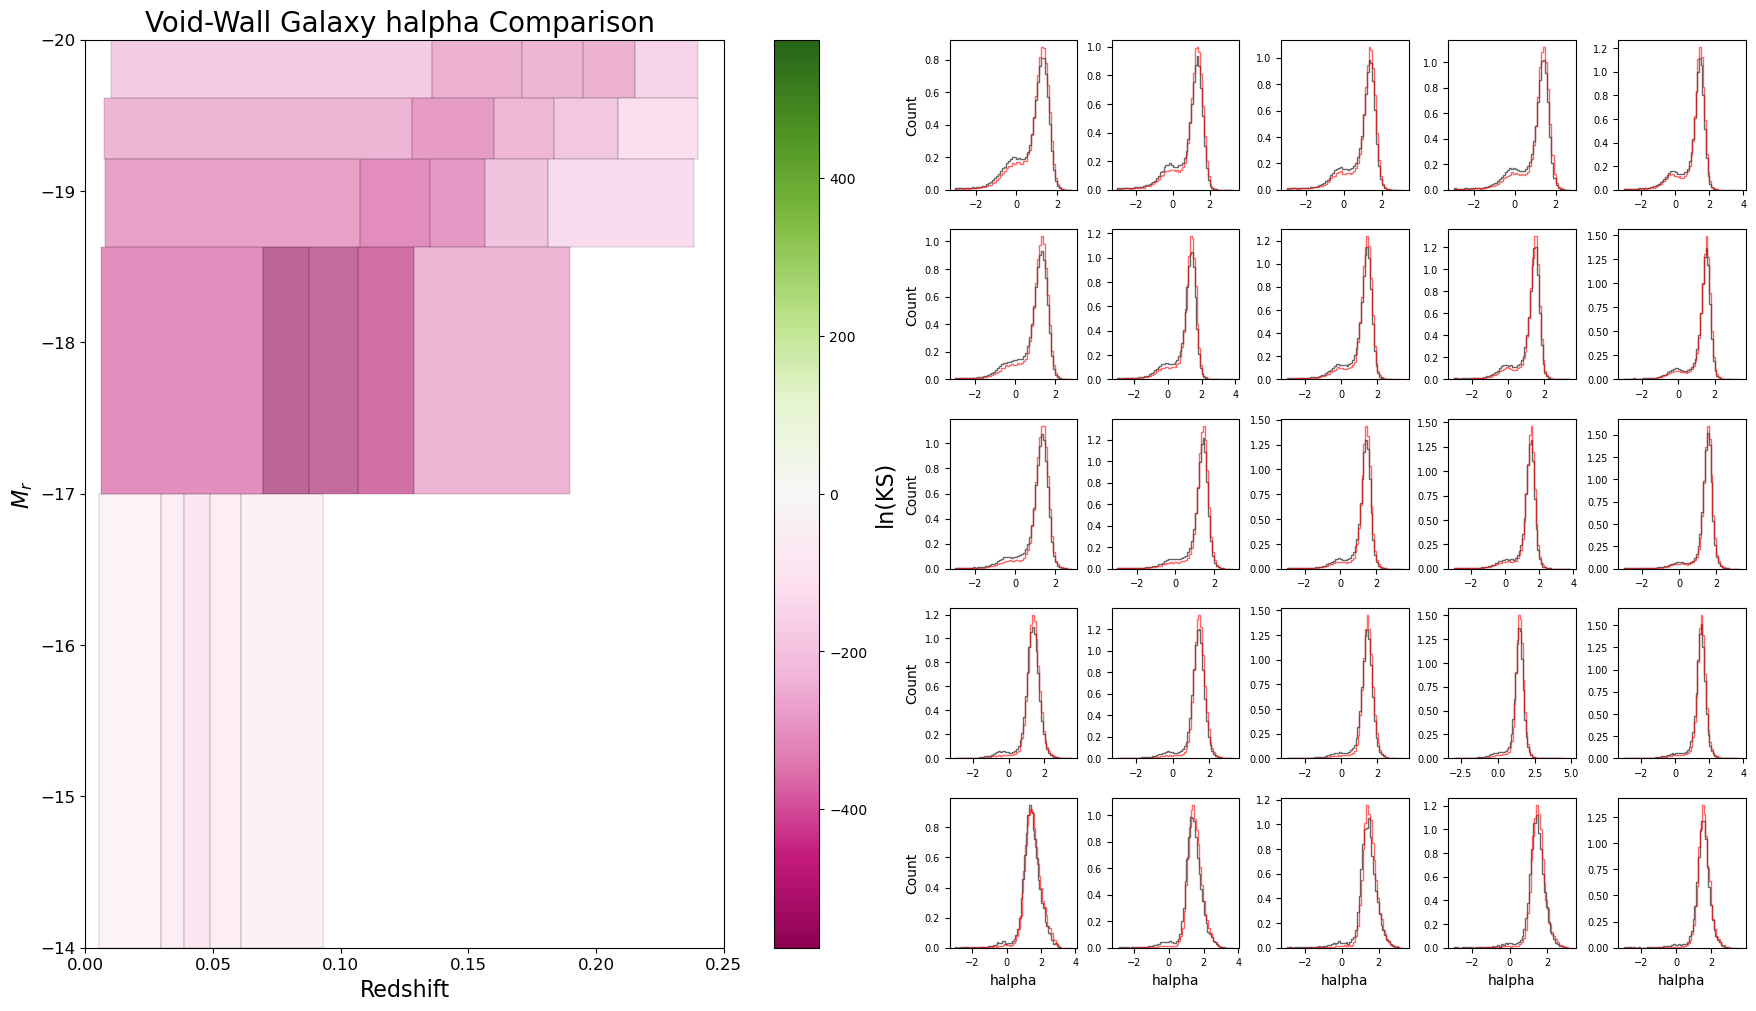

In [21]:
#Plot heatmap and density histograms
for property in ['log_mstar','g-r','u-r','halpha']:
    plot_heatmap_and_hist(property, num_mr_bins=5, num_z_bins=5, mr_min=-20, mr_max=-14, sample='BGS', lim17 = True)

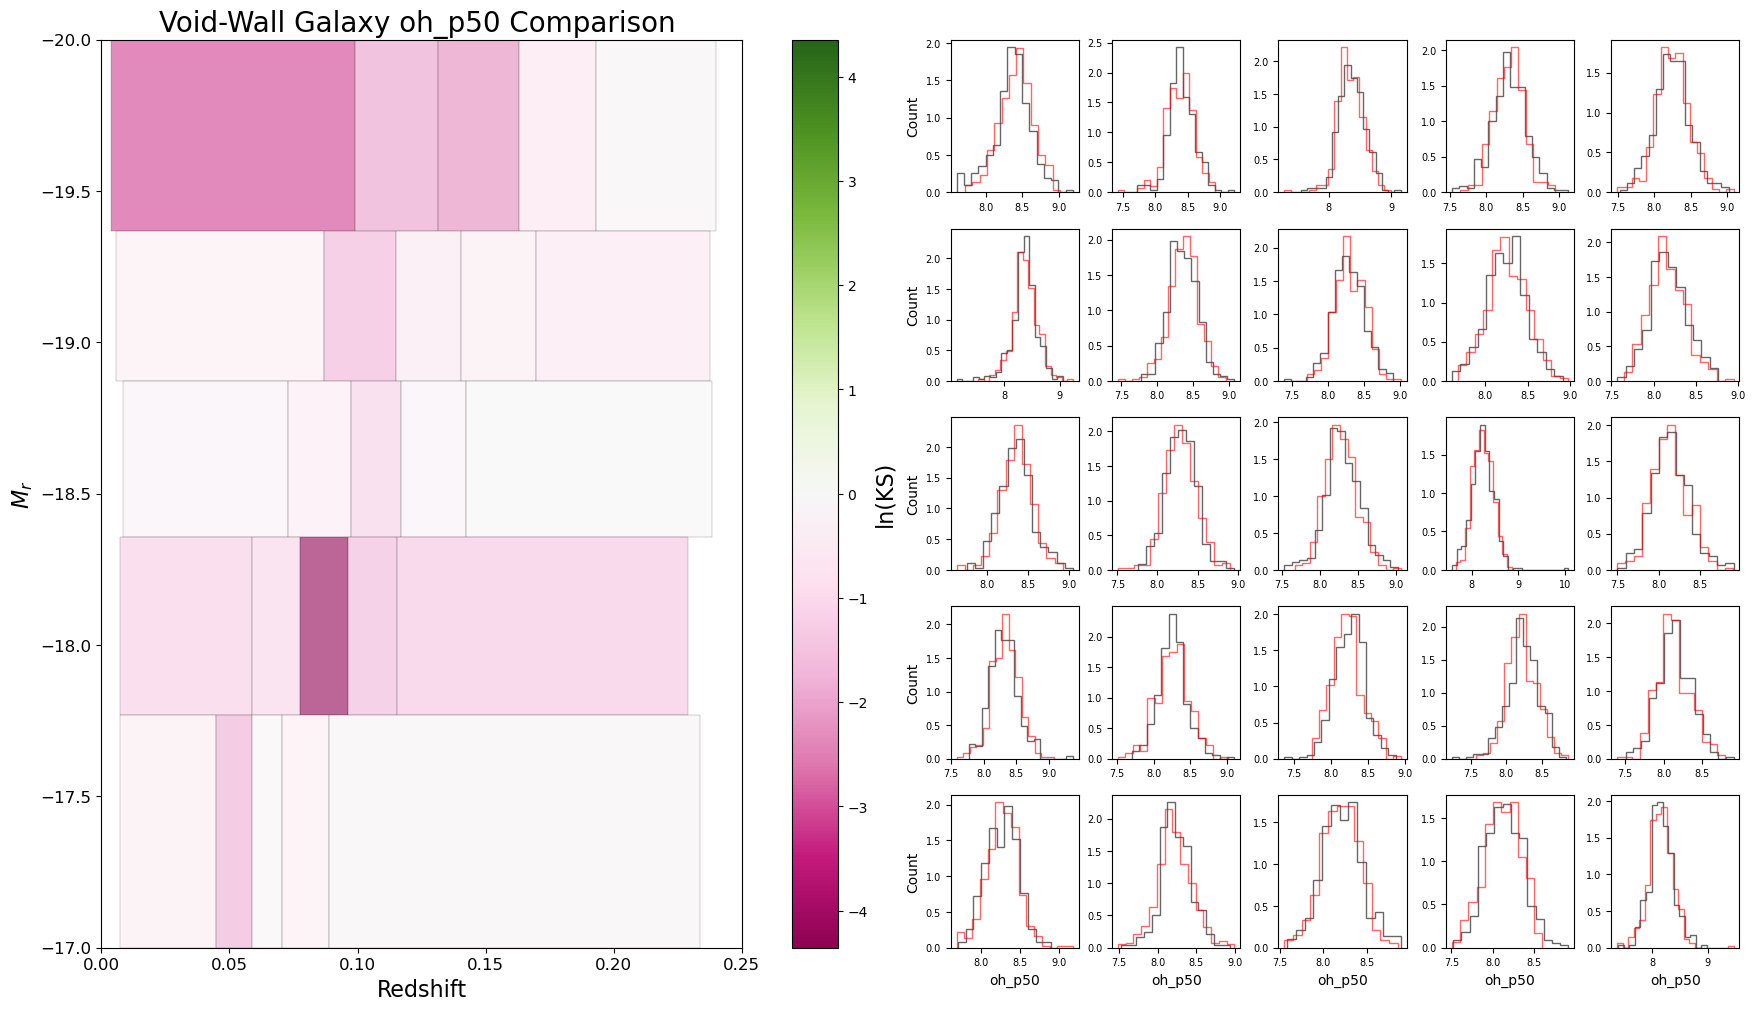

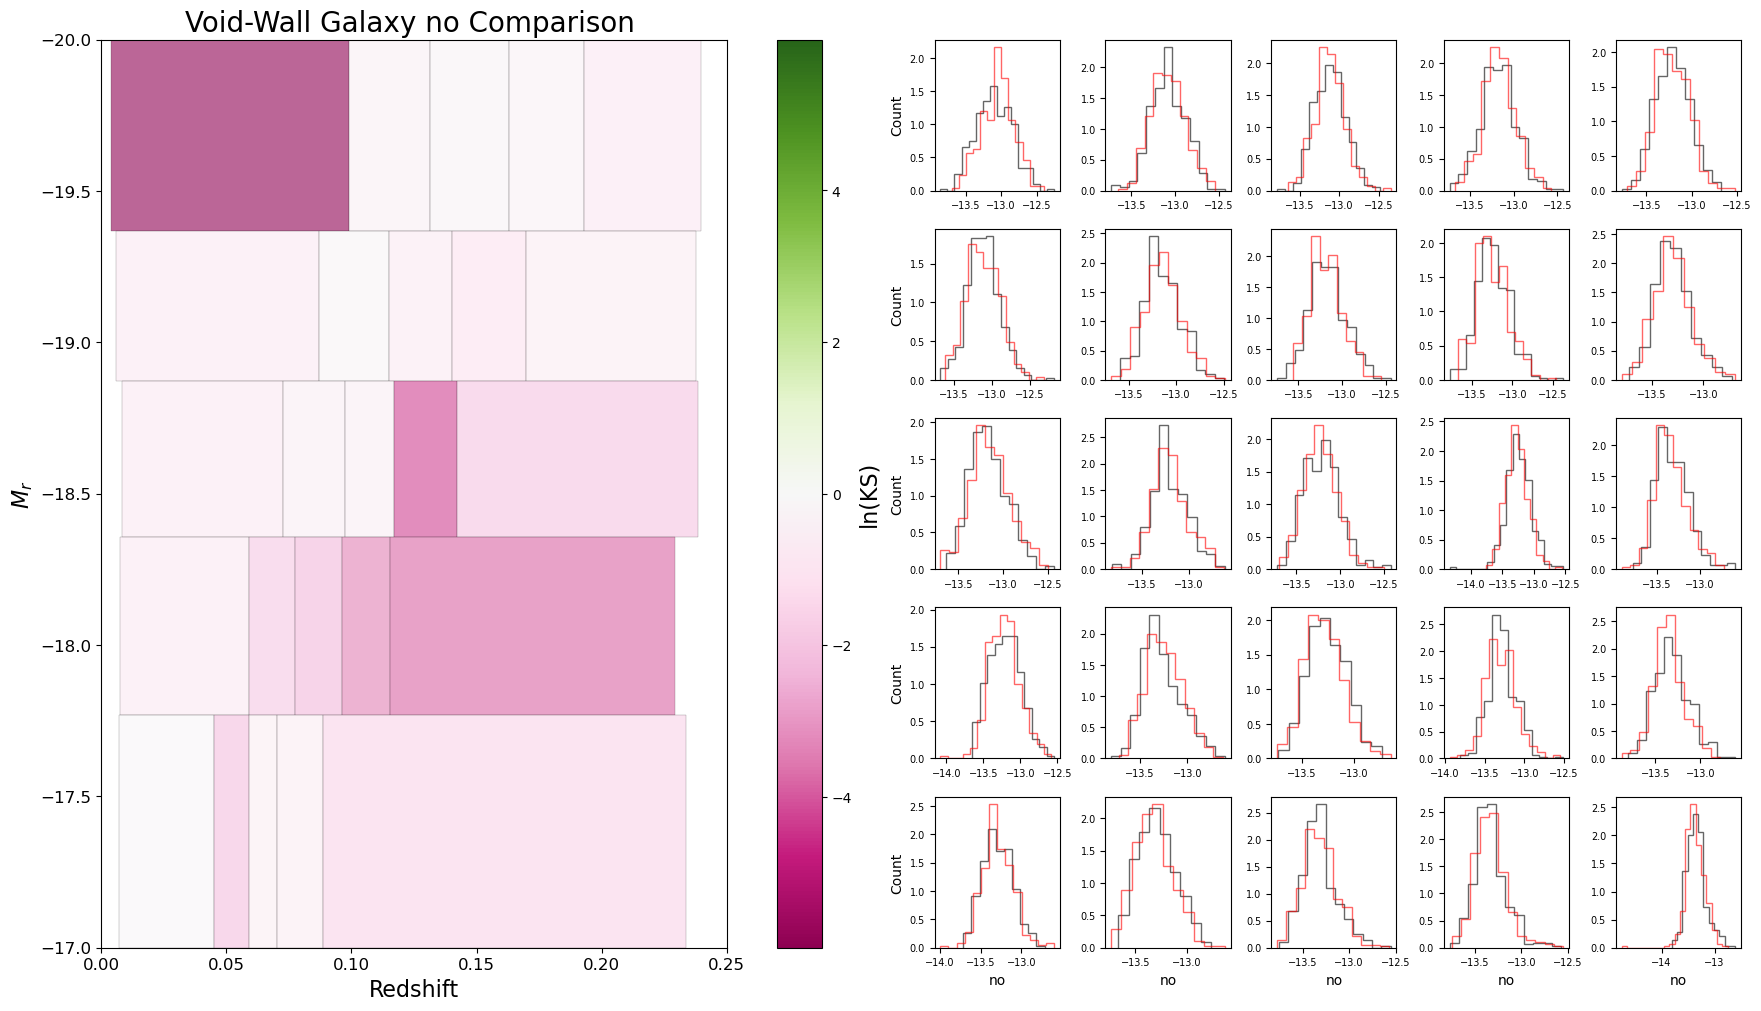

In [16]:
#Plot Metallicity heatmaps and density histograms
for property in ['oh_p50', 'no']:
    plot_heatmap_and_hist(property, num_mr_bins=5, num_z_bins=5, mr_min=-20, mr_max=-17, sample='BGS', lim17 = False)

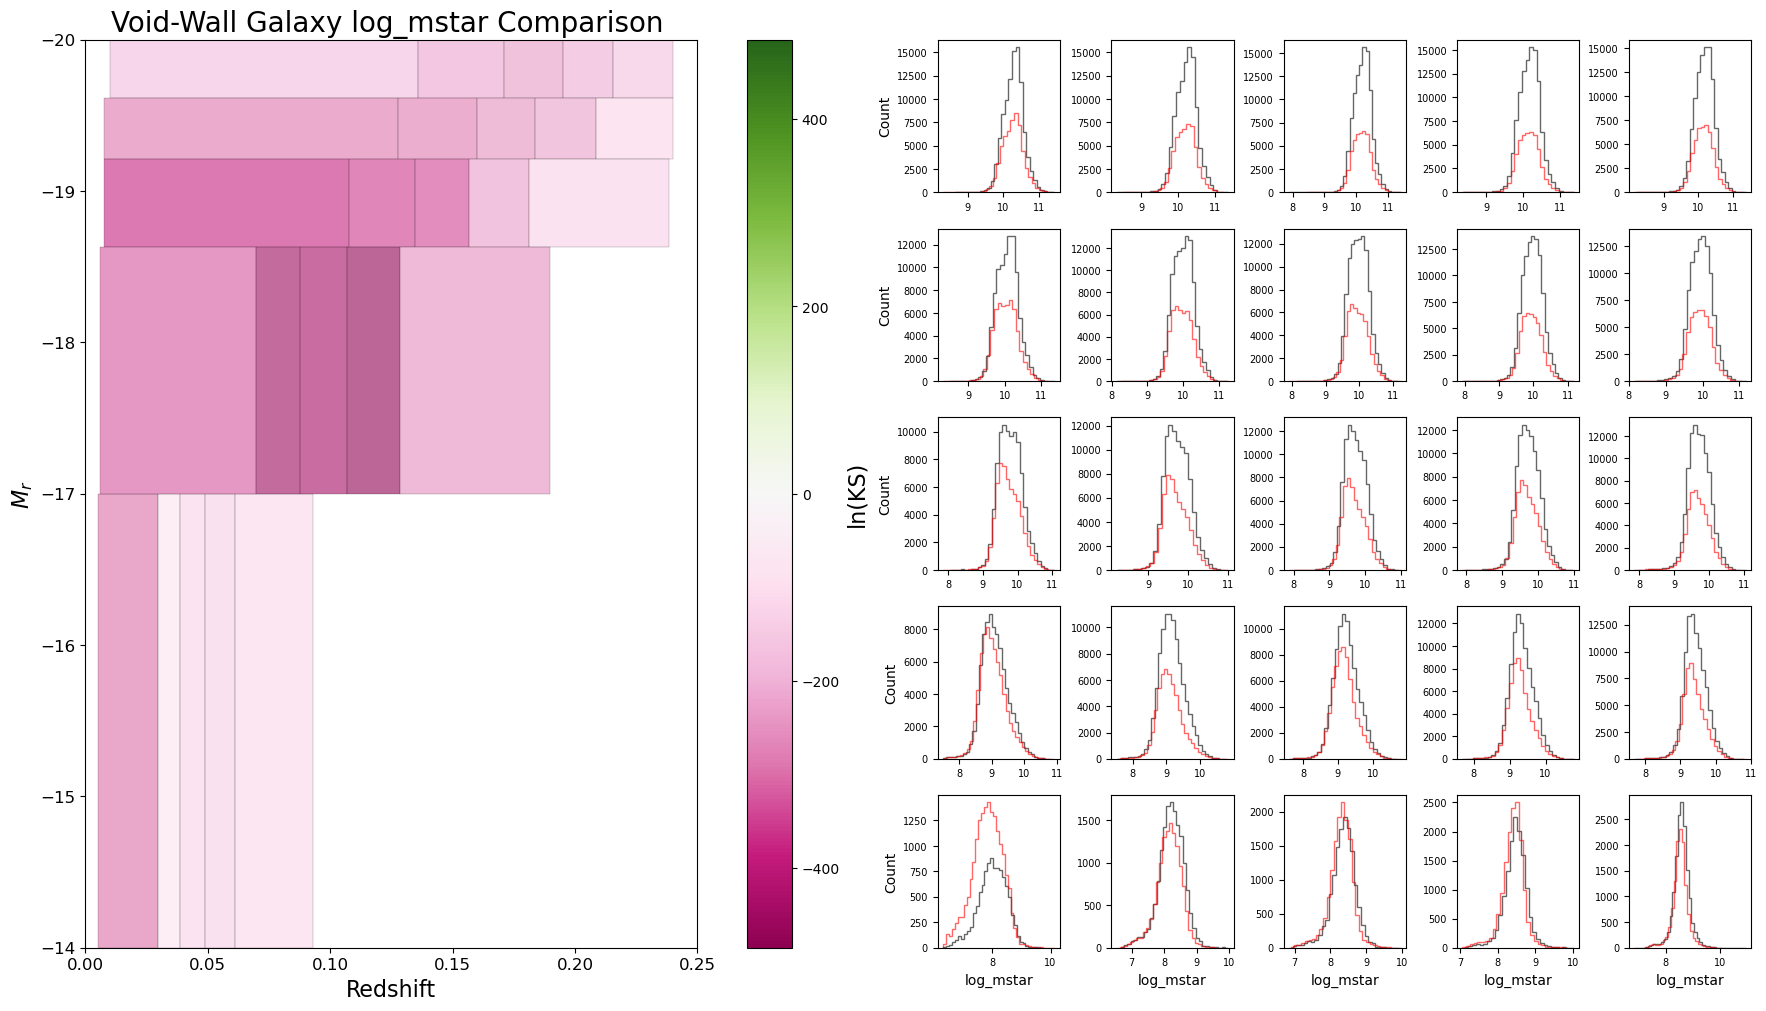

/tmp/ipykernel_273222/8898748.py:85: RuntimeWarning: divide by zero encountered in log
  ks = np.log(ks_2samp(wall_bin, void_bin).pvalue)


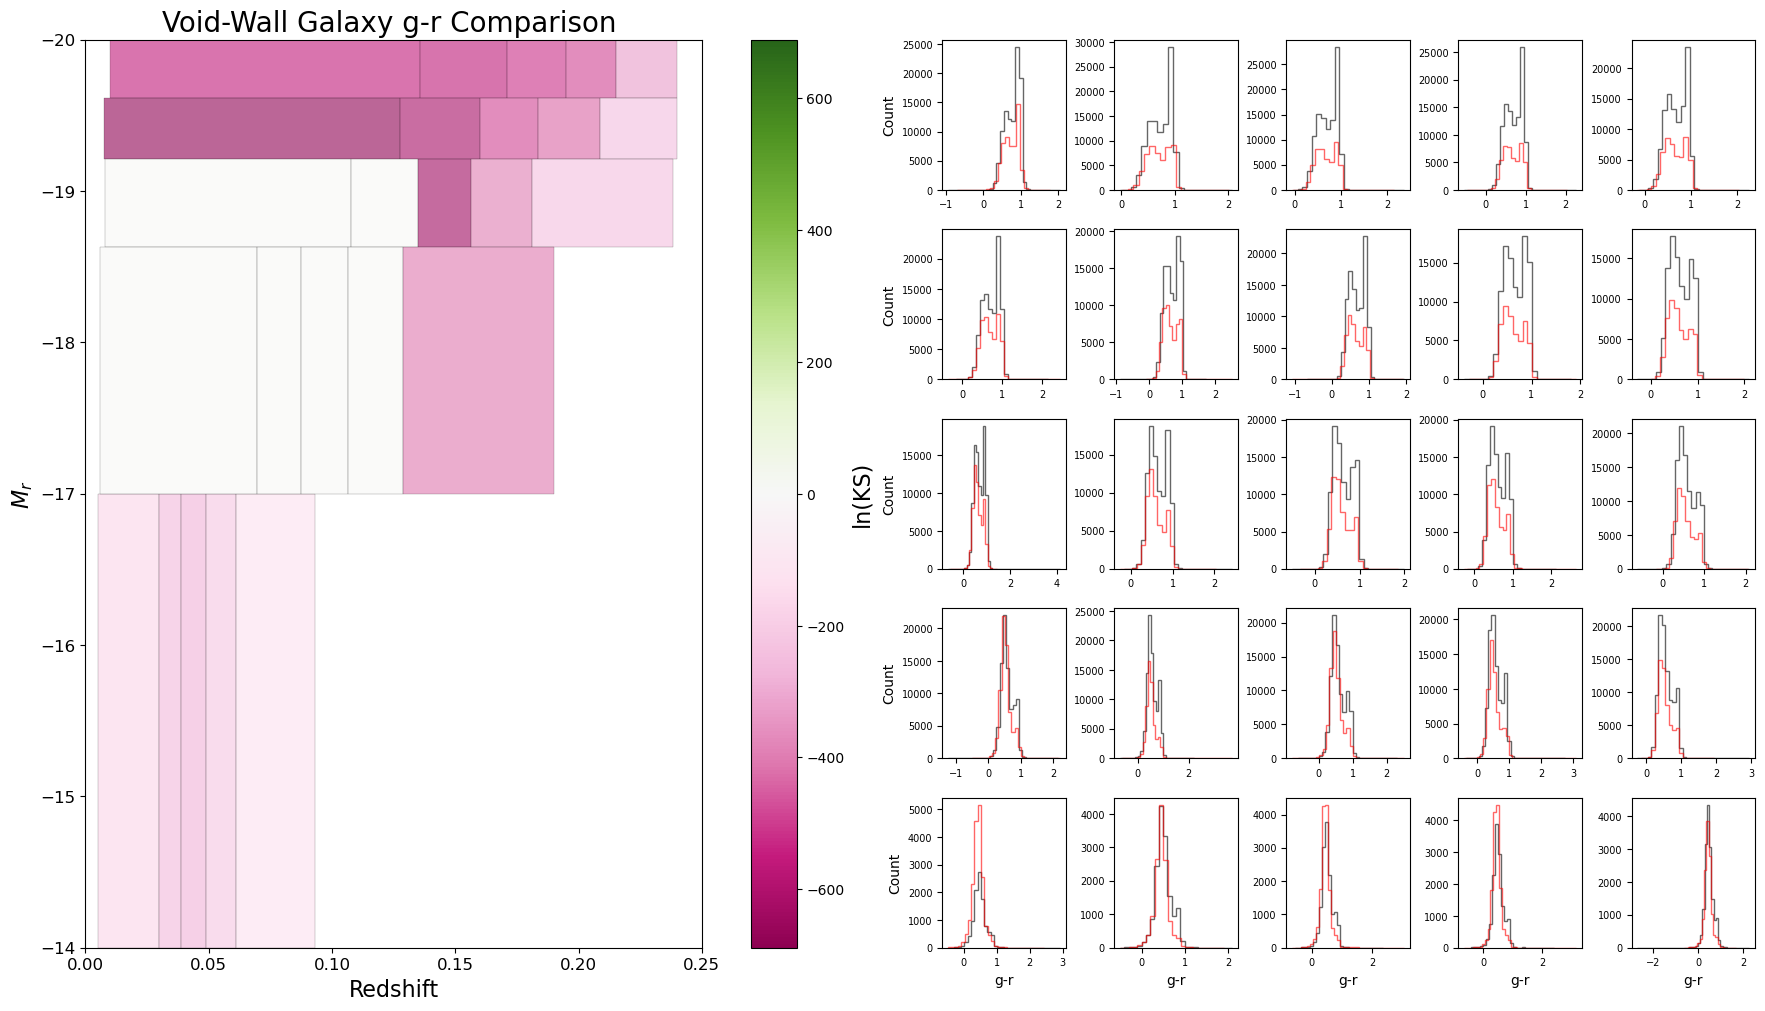

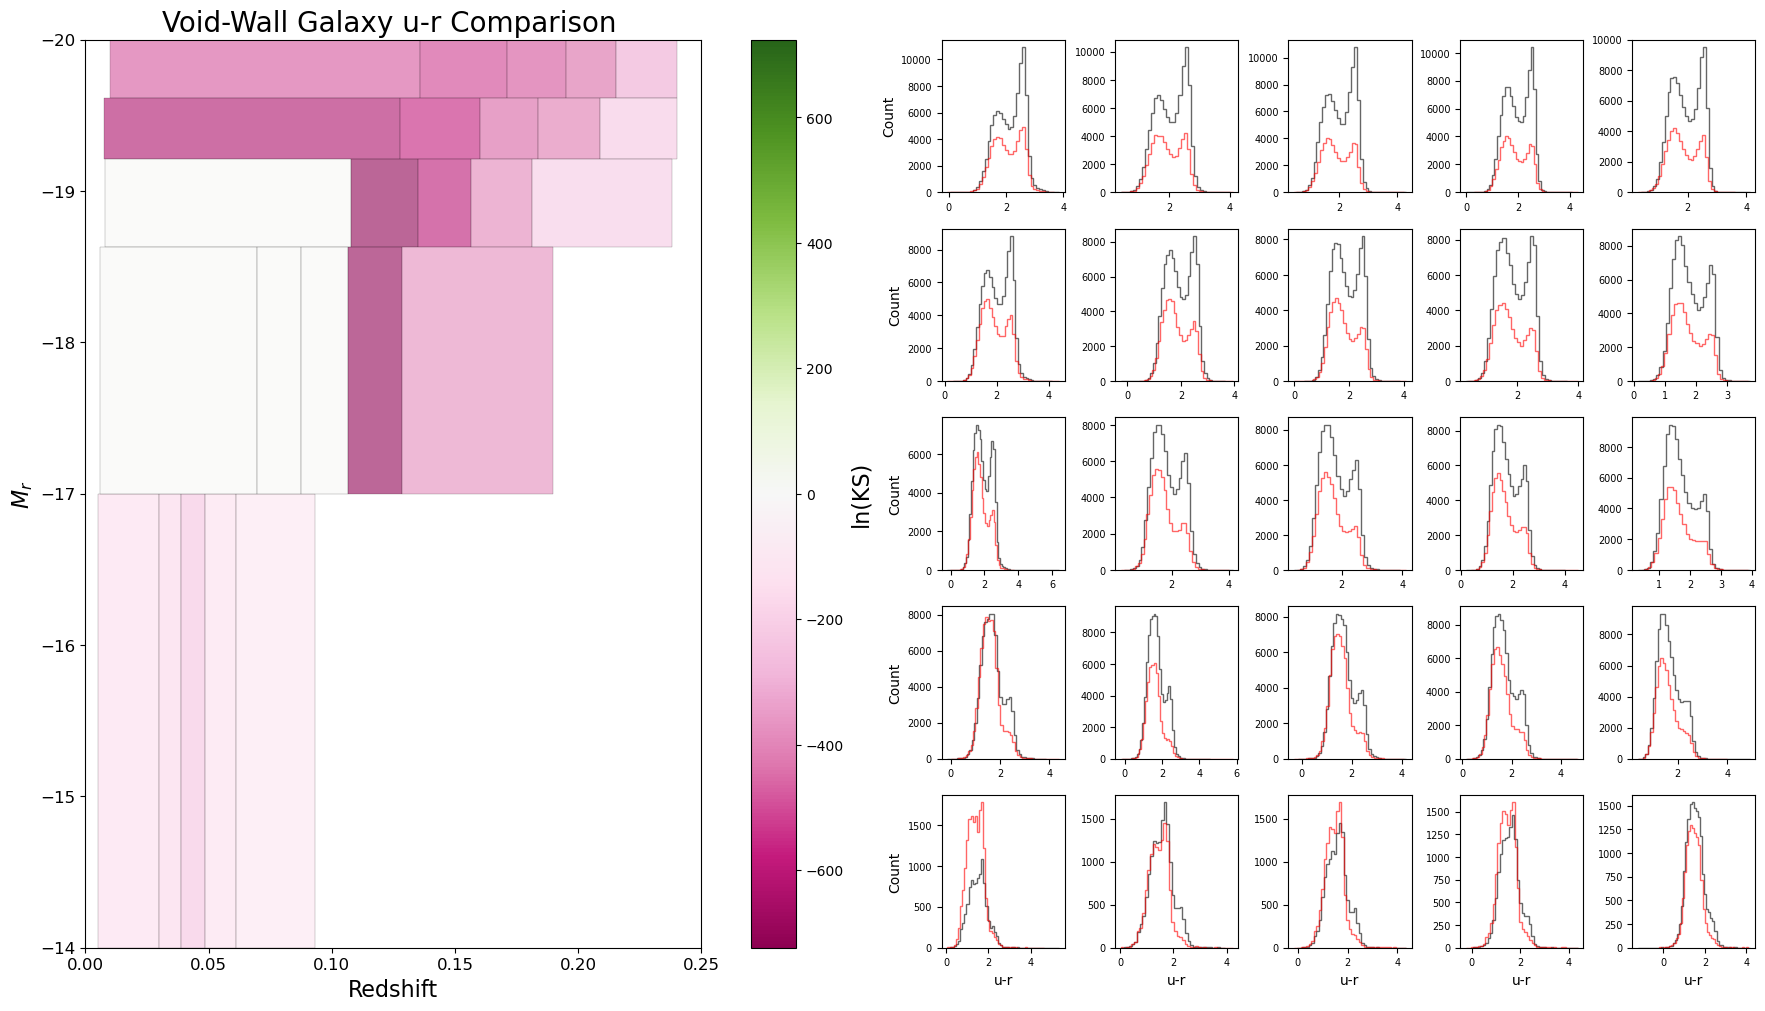

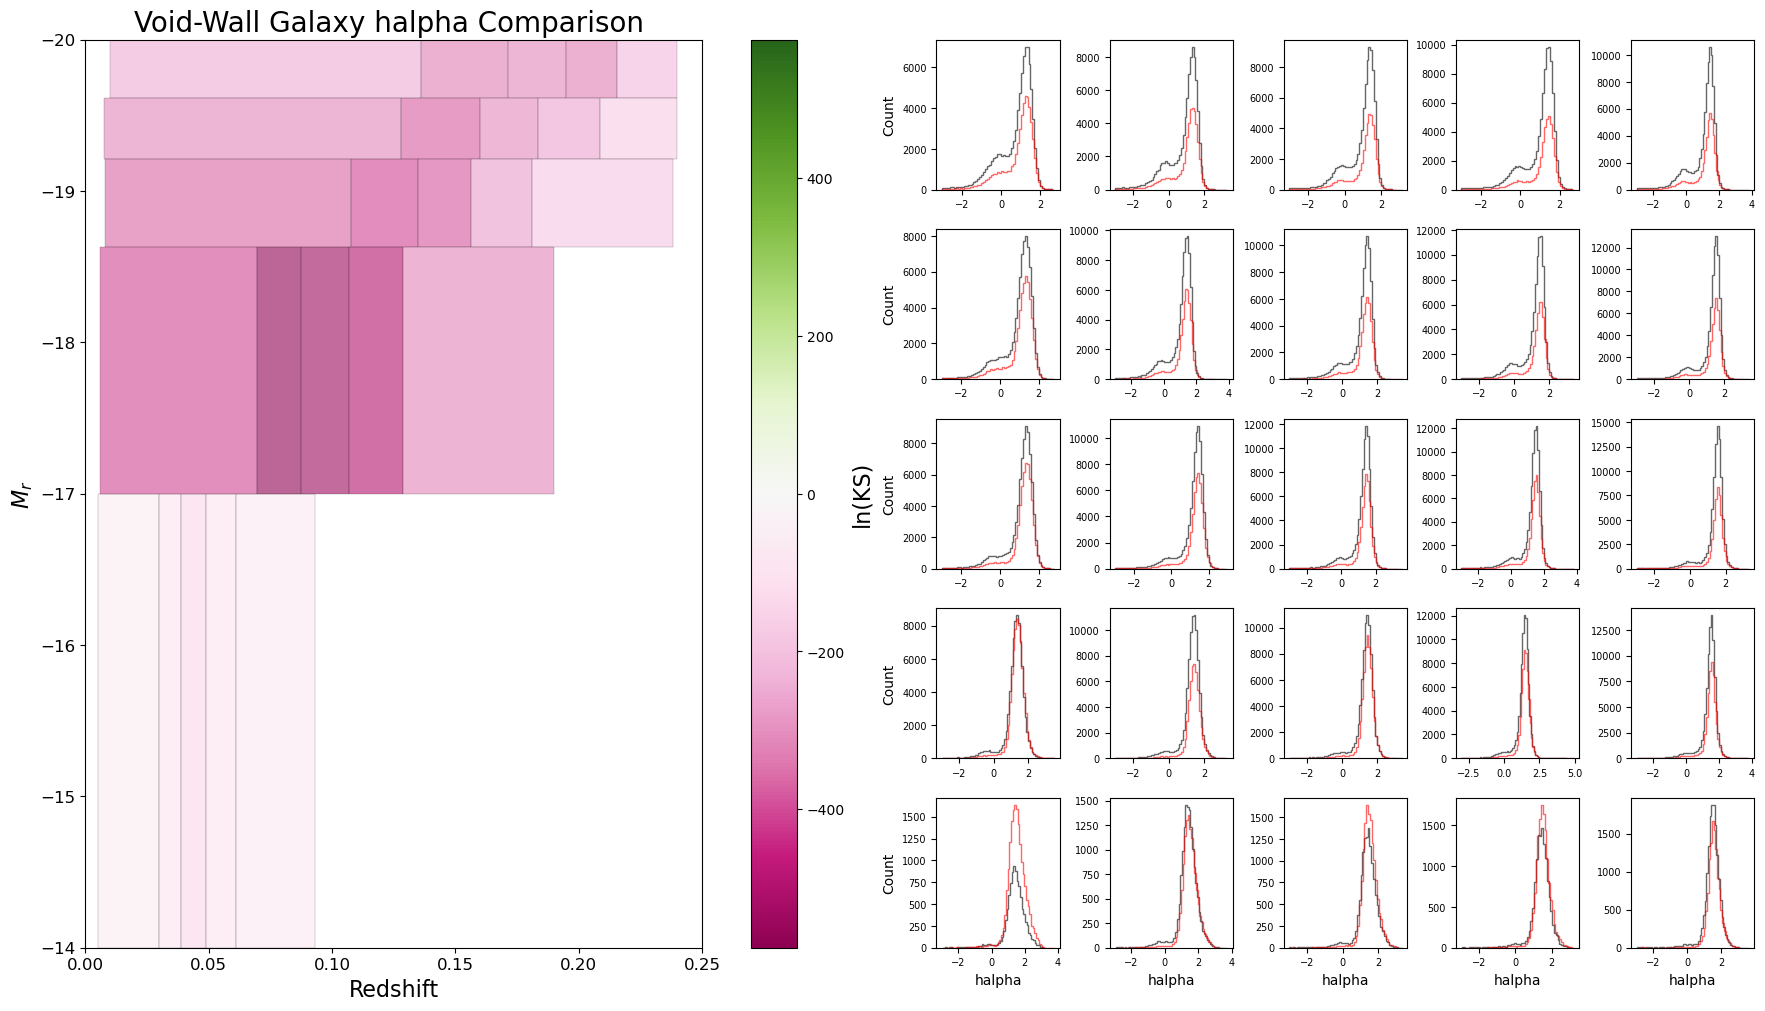

In [22]:
#Plot heatmap and counts histograms
for property in ['log_mstar','g-r','u-r','halpha']:
    plot_heatmap_and_hist(property, num_mr_bins=5, num_z_bins=5, mr_min=-20, mr_max=-14, sample='BGS', lim17 = True, density = False)

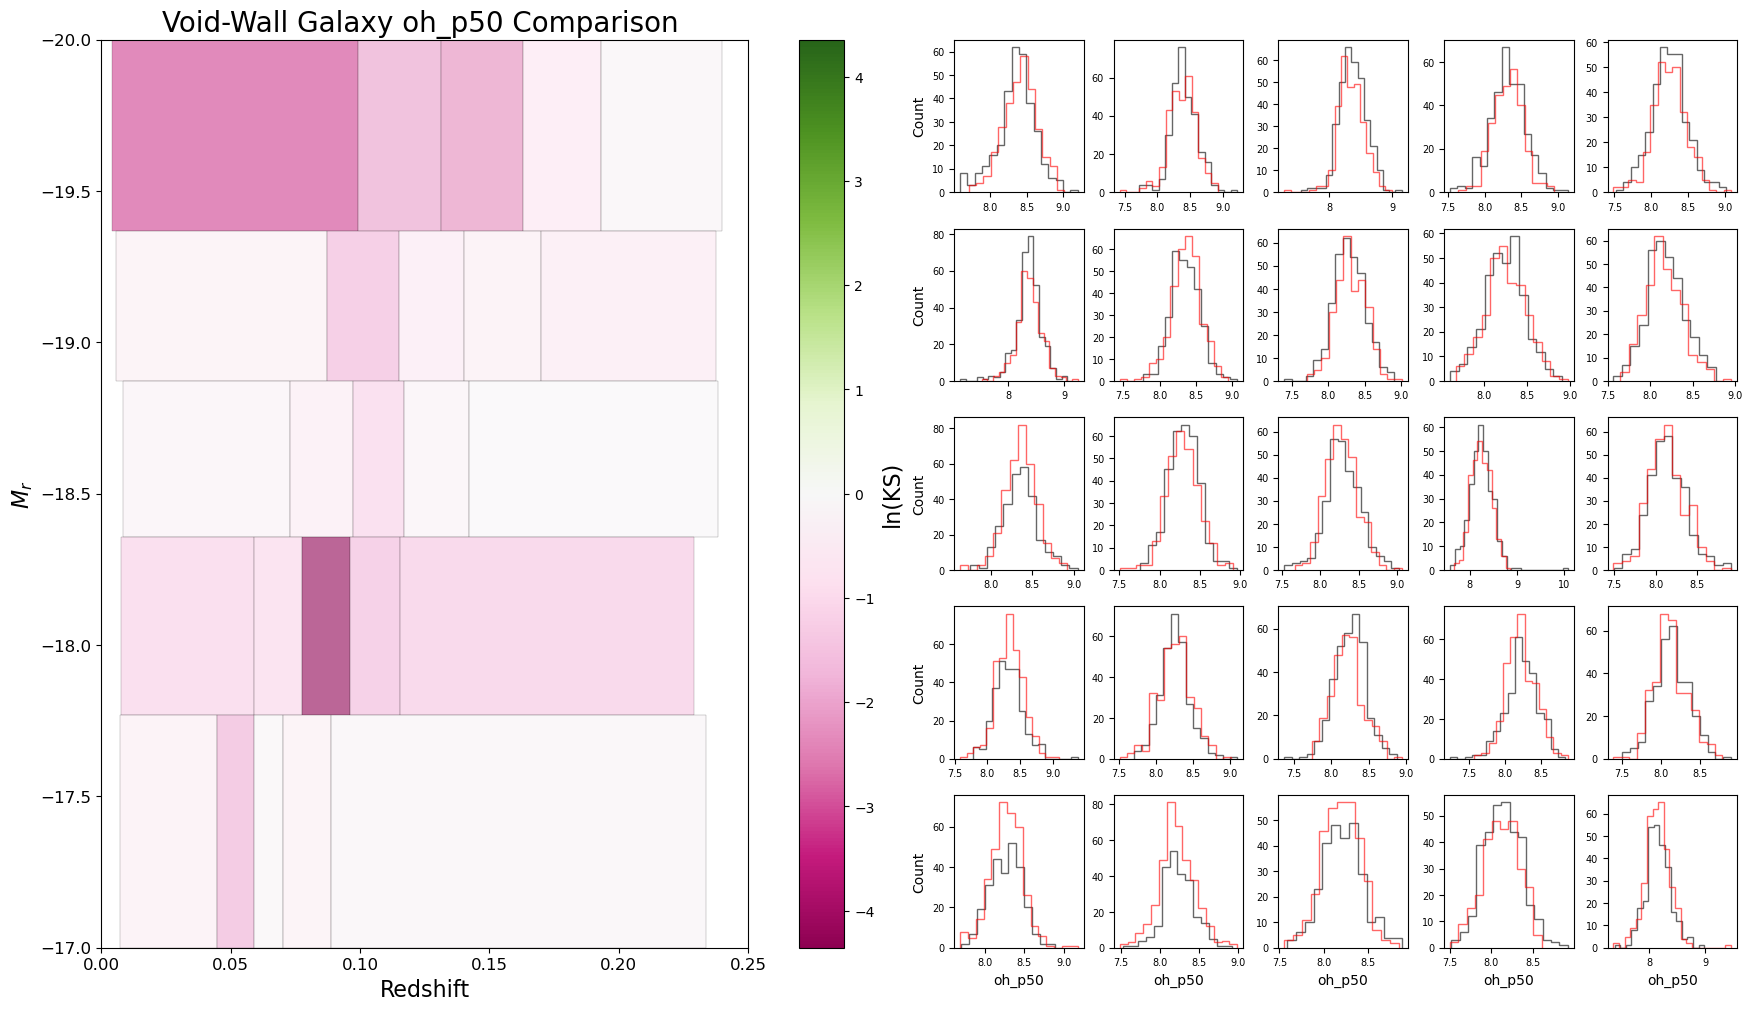

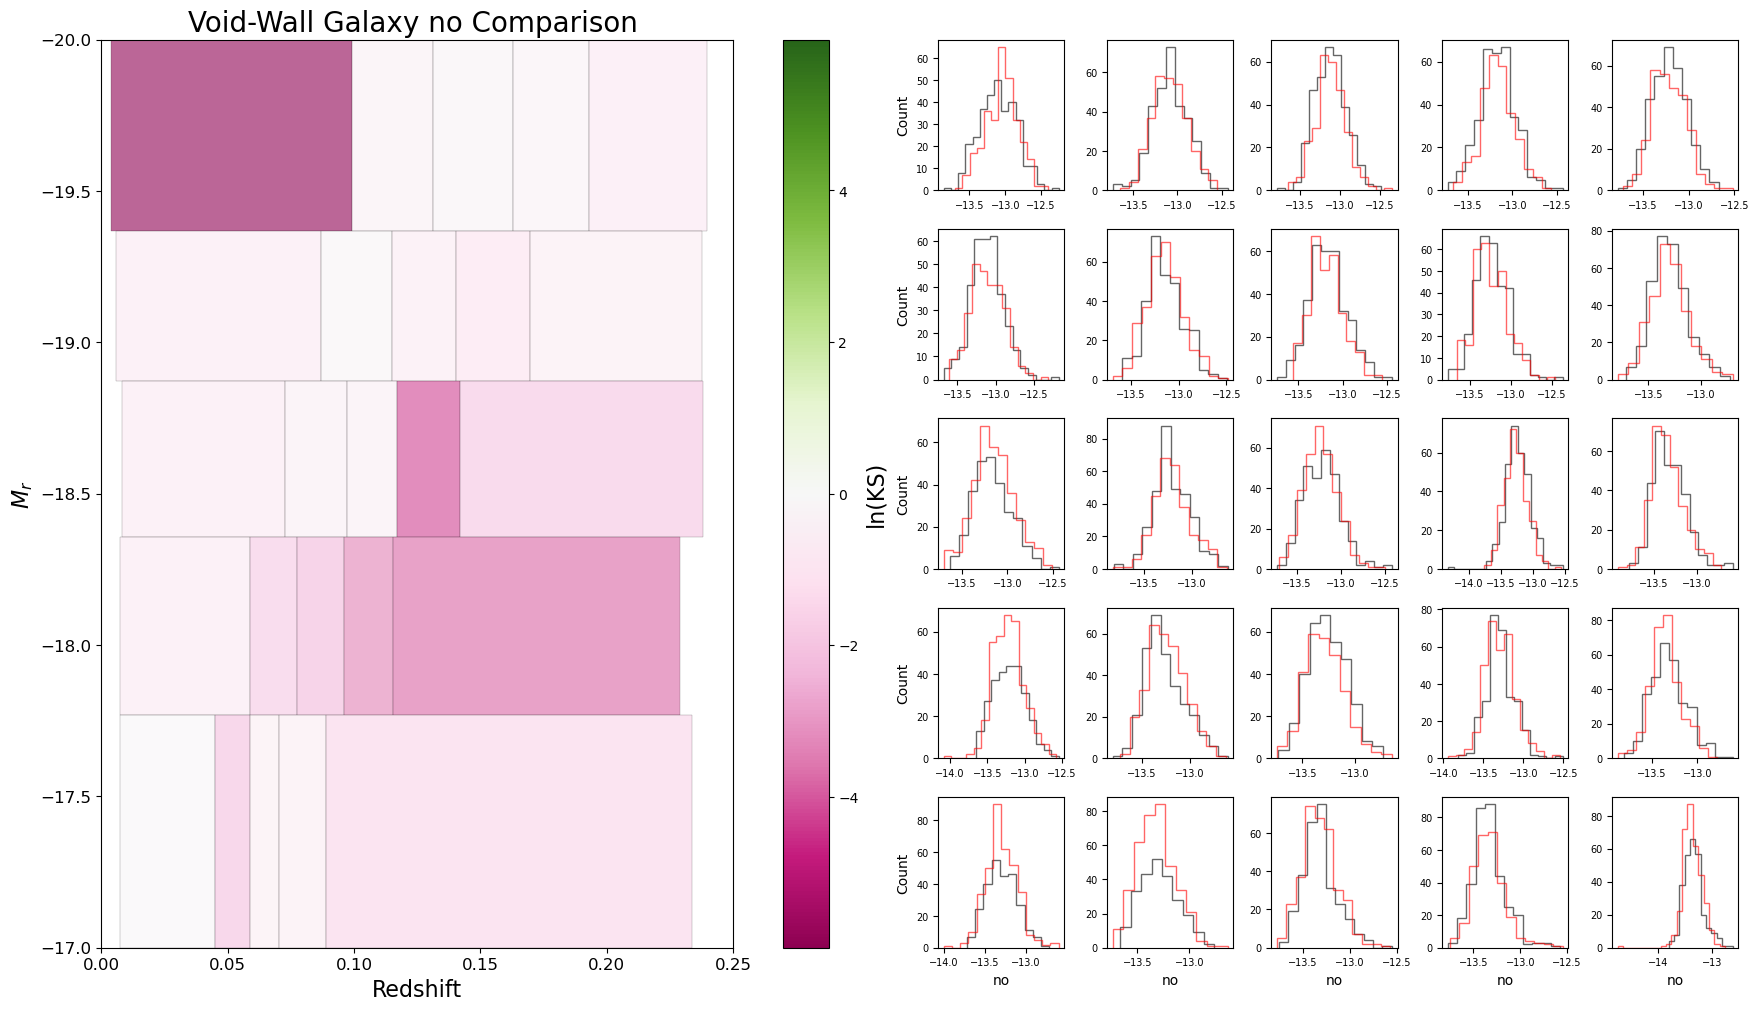

In [18]:
#Plot Metallicity heatmaps and counts histograms
for property in ['oh_p50', 'no']:
    plot_heatmap_and_hist(property, num_mr_bins=5, num_z_bins=5, mr_min=-20, mr_max=-17, sample='BGS', lim17 = False, density = False)